# Exploration approfondie de la base d'apprentissage

In [4]:
import pandas as pd
import sys
import os
import warnings

warnings.filterwarnings("ignore")

# On connecte le notebook à tous les fichiers inclus dans le dossier /fonctions
sys.path.insert(0, os.path.abspath("../fonctions"))

%load_ext autoreload
%autoreload 

from eda import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
# Configuration
FILE_PATH = "../data_finale/train.csv"
TARGET    = "market_value_in_eur"
dossier_sauvegarde = "../outputs/eda"

In [6]:
# Chargement de la base de données

df_base = pd.read_csv(FILE_PATH)

In [7]:
print("Types des variables")

analyser_types(df_base)

Types des variables
Analyse des types de variables
Variables numériques   : 146
Variables catégorielles: 4


Analyse des valeurs manquantes
                         nb_missing    pct
contrat_jours_restants         2080  19.39
market_value_in_eur             916   8.54
market_value_in_eur_nor         916   8.54
nation                            2   0.02

Graphique sauvegardé sous : ..\outputs\eda\valeurs_manquantes.png


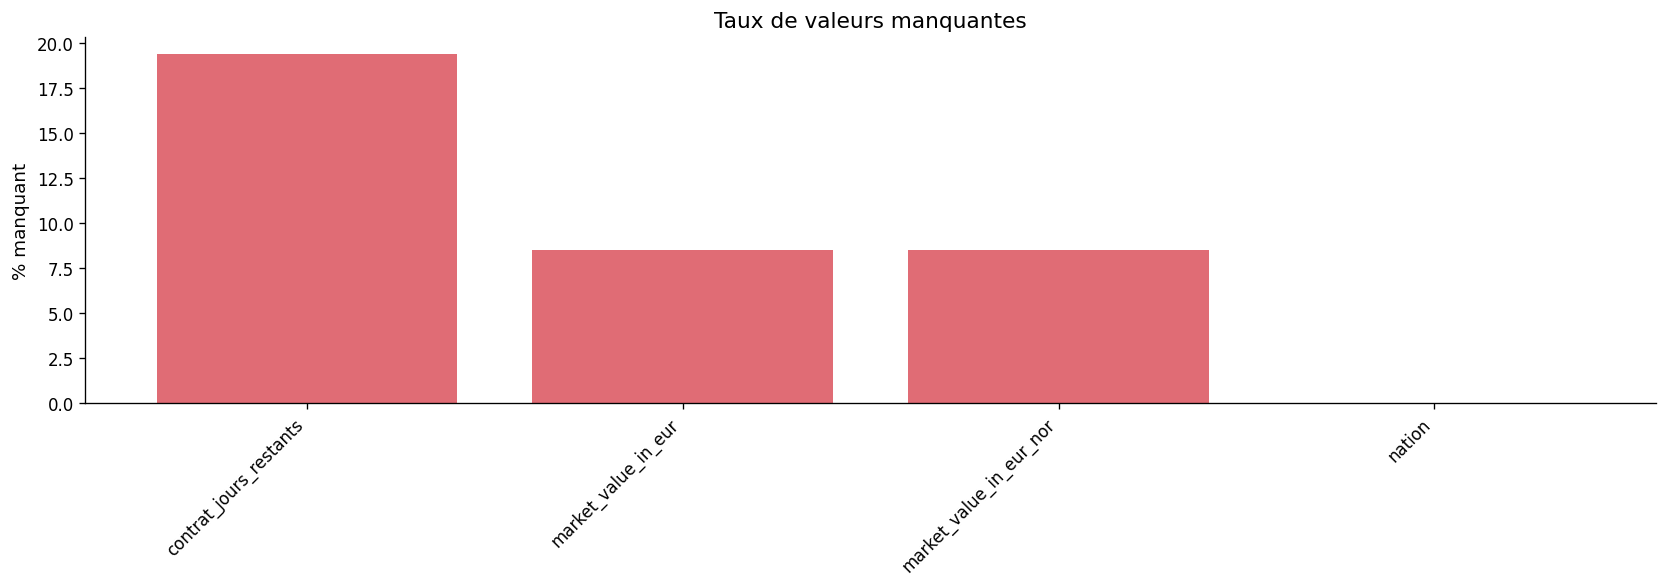

In [8]:
analyser_valeurs_manquantes(df_base, dossier_sauvegarde=dossier_sauvegarde)

Analyse de la variable cible : market_value_in_eur
count          9,813
mean      11,178,717
std       16,225,638
min           50,000
25%        2,000,000
50%        5,000,000
75%       14,000,000
max      180,000,000
Name: market_value_in_eur, dtype: str

Skewness : 3.44
Kurtosis : 18.13

Graphique sauvegardé sous : ..\outputs\eda\distribution_market_value_in_eur.png


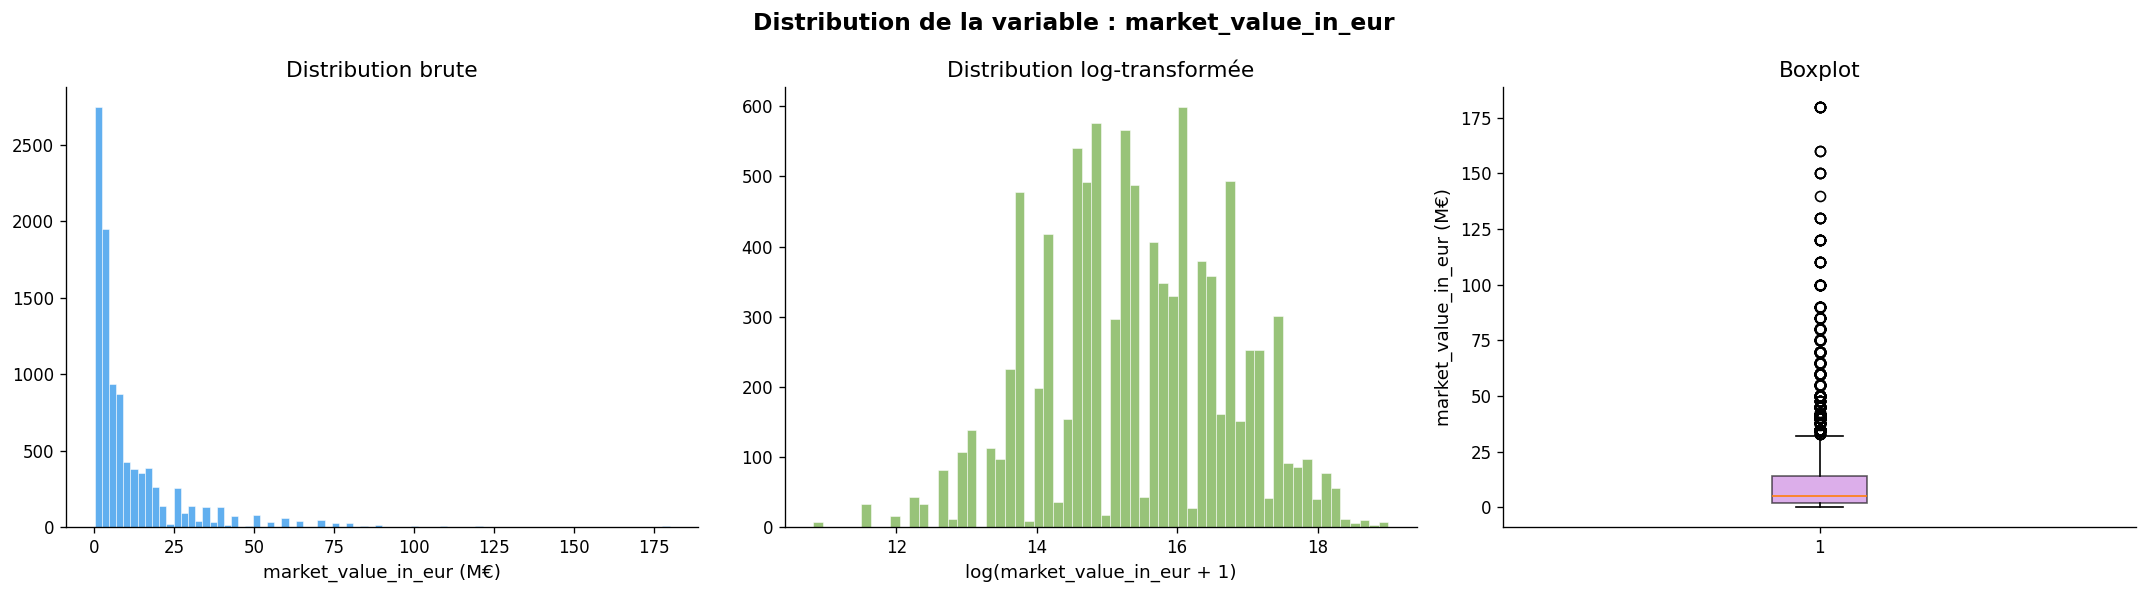

In [9]:
analyser_variable_cible(df_base, target_col=TARGET, dossier_sauvegarde=dossier_sauvegarde)

Distributions des variables numériques clés

Graphique sauvegardé sous : ..\outputs\eda\distributions_variables_numeriques_cles.png


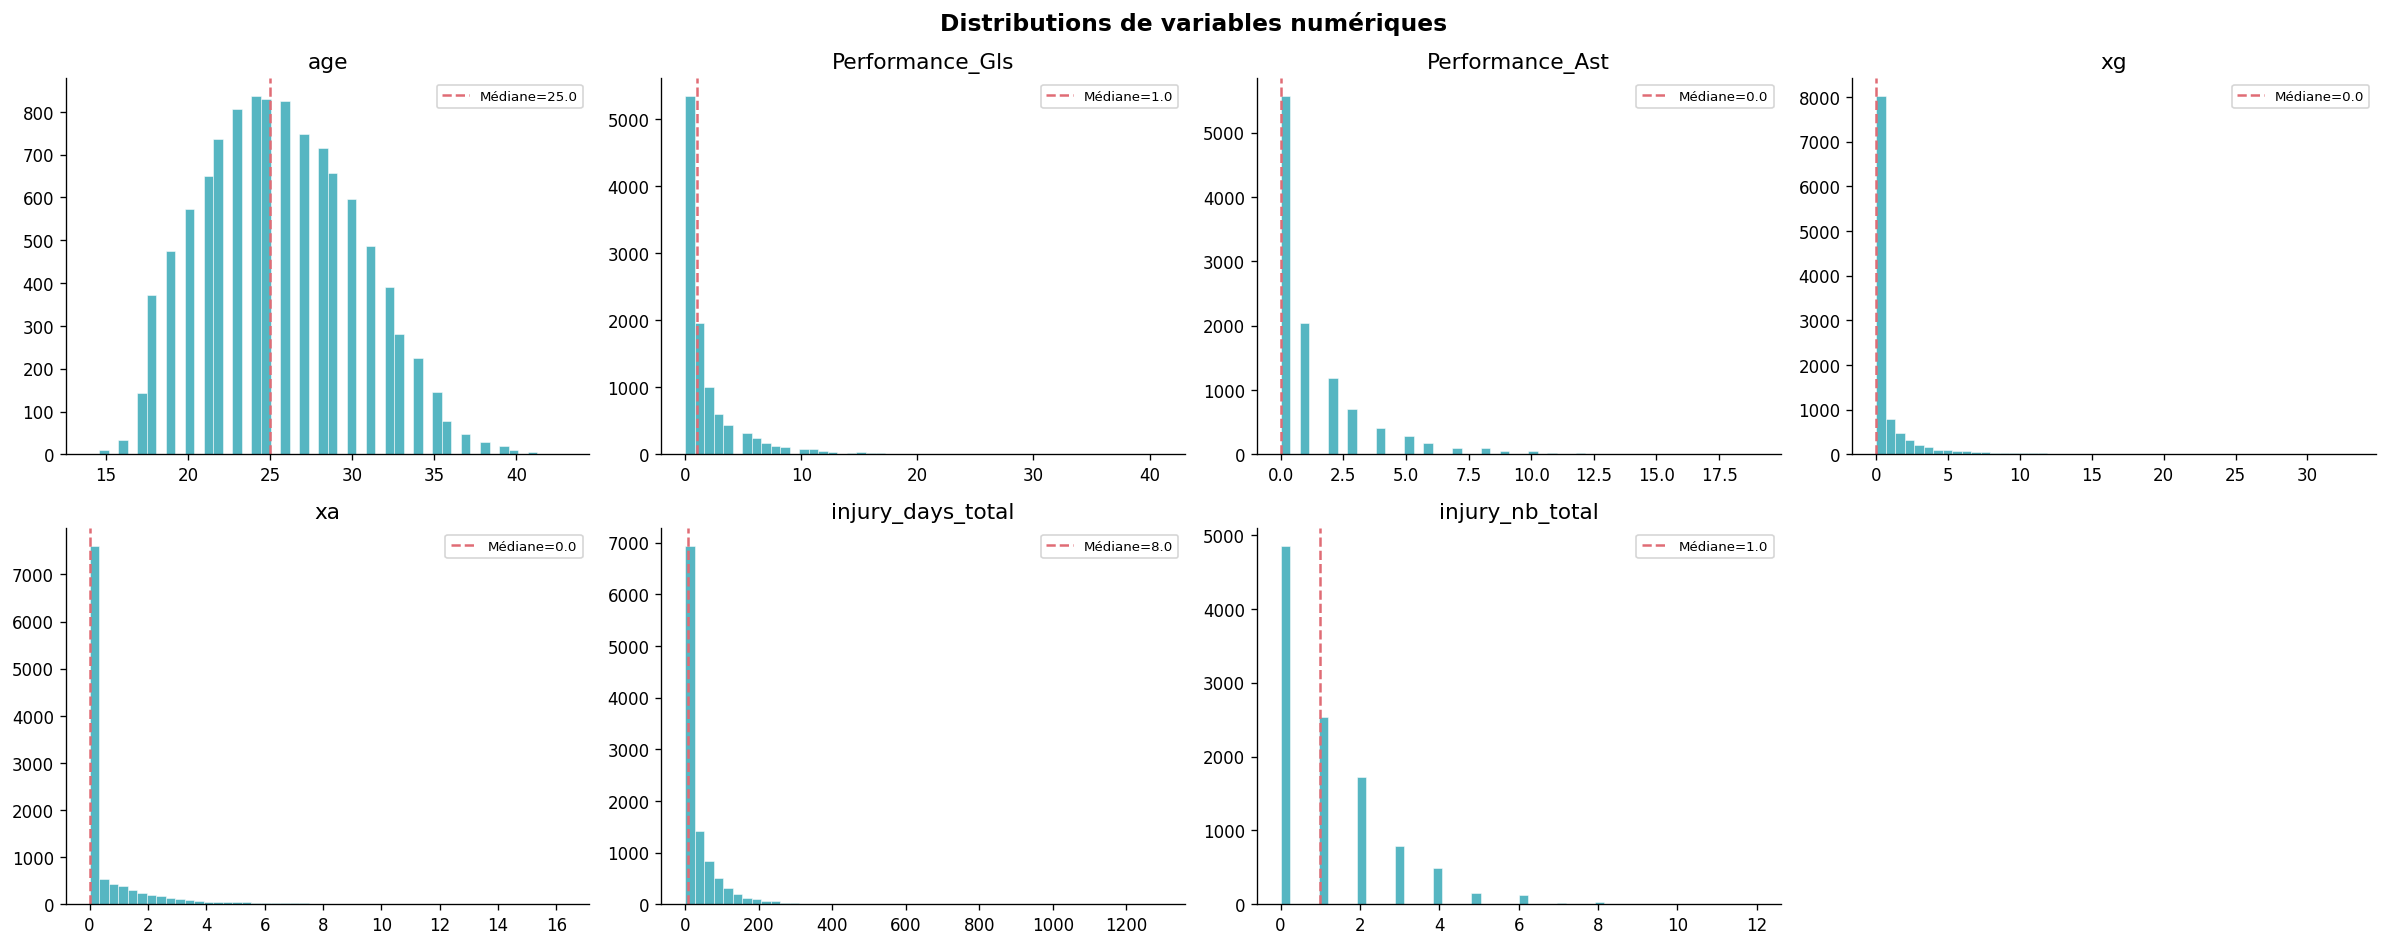

In [10]:
analyser_distributions_numeriques(df_base, cols_a_analyser=None, dossier_sauvegarde=dossier_sauvegarde)

Analyse des variables catégorielles

league (5 modalités encodées) :
ITA-Serie A           2281
ESP-La Liga           2264
FRA-Ligue 1           2177
ENG-Premier League    2085
GER-Bundesliga        1922

players_top_nations.png sauvegardé


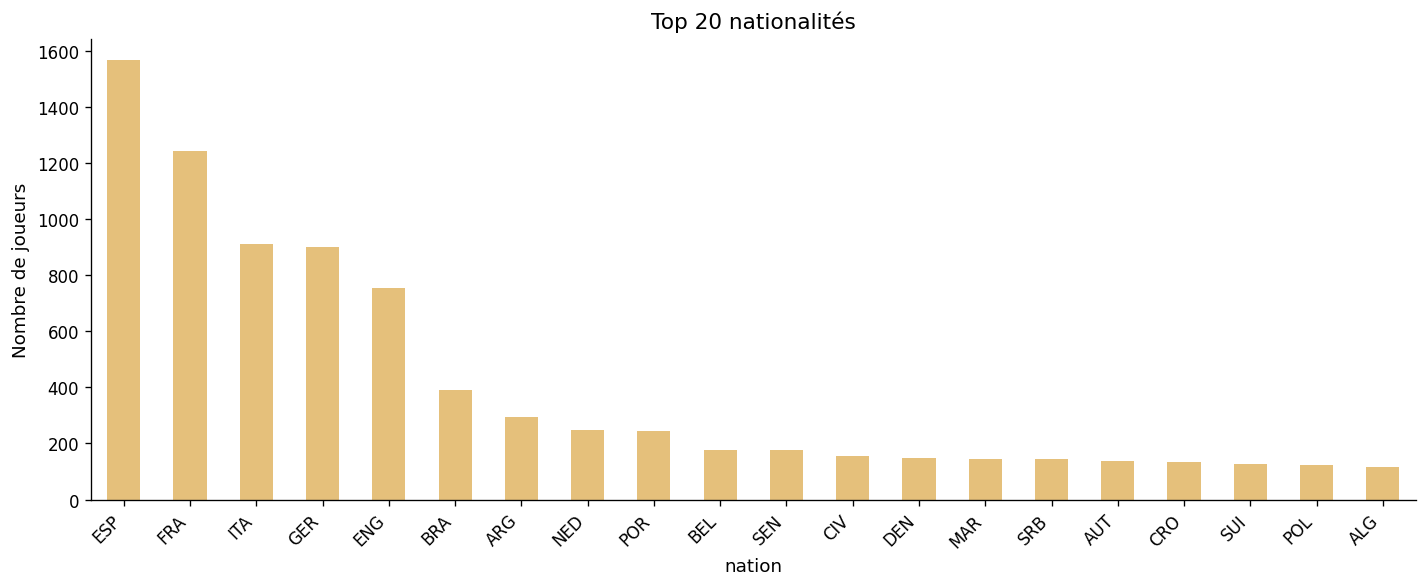

league.png sauvegardé


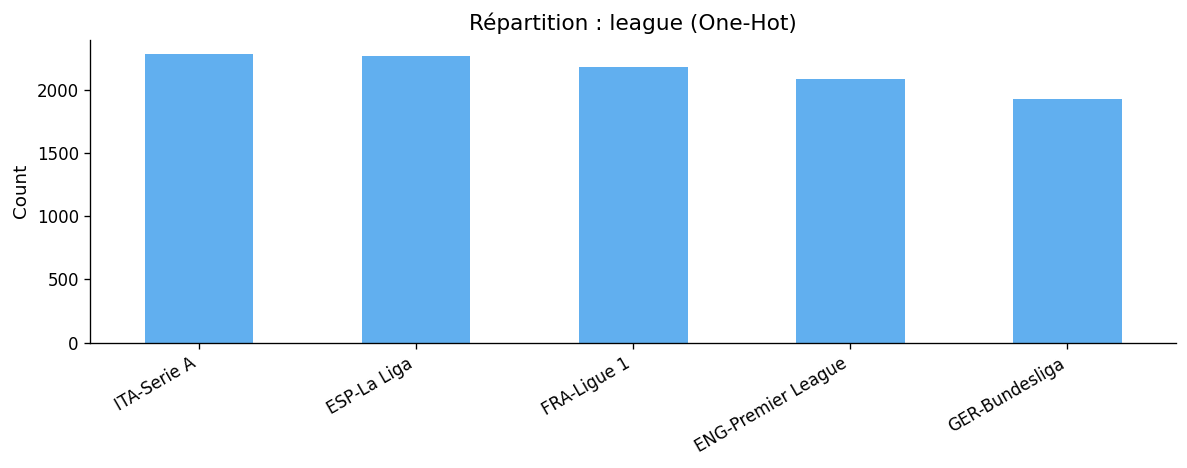

vm_par_league.png sauvegardé


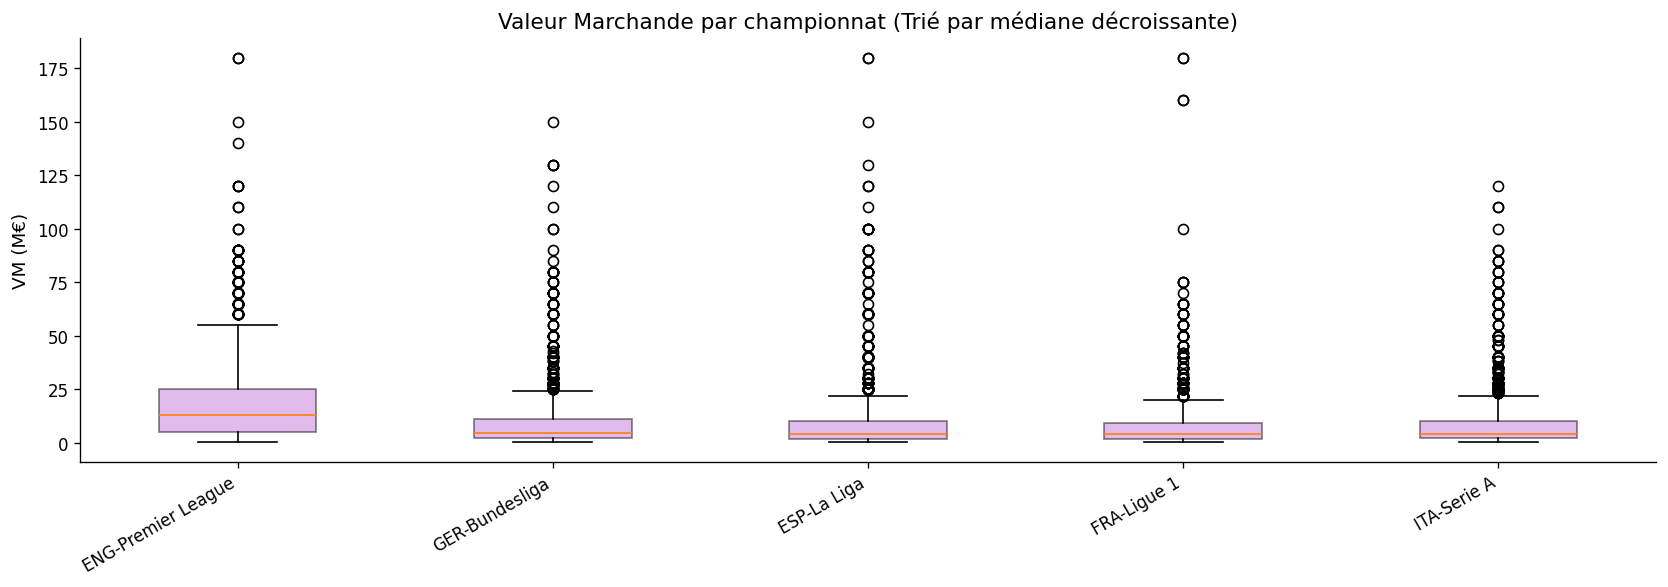

In [11]:
analyser_variables_categorielles(df_base, TARGET, dossier_sauvegarde=dossier_sauvegarde)

In [12]:
analyser_outliers(df_base)

Détection des outliers
         variable  outliers_IQR  pct_IQR  outliers_Zscore  total
              age            16      0.1               16  10729
  Performance_Gls          1060      9.9              261  10729
  Performance_Ast           534      5.0              248  10729
               xg          1608     15.0              257  10729
               xa          1599     14.9              320  10729
injury_days_total           908      8.5              213  10729
  injury_nb_total           177      1.6              177  10729


Analyse des corrélations (cible : market_value_in_eur)

Corrélation linéaire avec la cible (variables clés)
                     market_value_in_eur
market_value_in_eur             1.000000
Performance_Gls                 0.484764
Performance_Ast                 0.458582
xg                              0.297810
xa                              0.287994
injury_nb_total                 0.119958
injury_days_total               0.034985
age                            -0.164871

matrice_correlation.png sauvegardé sous : ..\outputs\eda\matrice_correlation.png


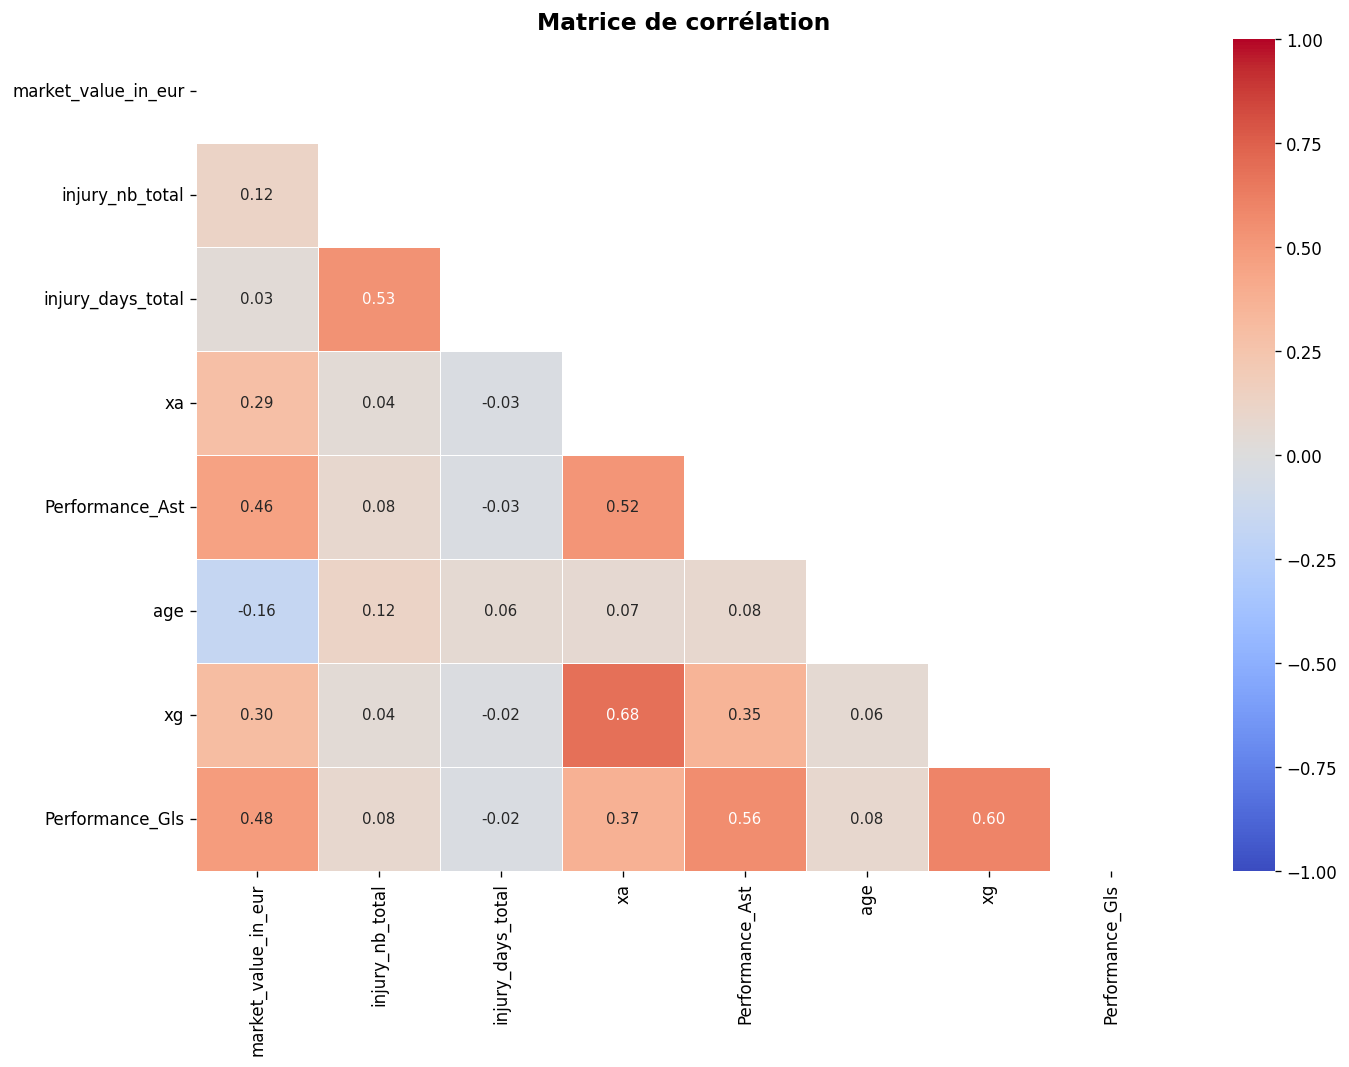


Top 20 des corrélations absolues avec market_value_in_eur (Toutes variables numériques)
market_value_in_eur_nor    1.000000
Team Success_onG           0.574600
Standard_Sh                0.493673
Standard_Sh_nor            0.493673
Standard_SoT               0.489907
Standard_SoT_nor           0.489907
Performance_G-PK           0.489717
Performance_Gls            0.484764
Performance_Gls_nor        0.484764
Performance_Ast            0.458582
Performance_Ast_nor        0.458582
Playing Time_90s           0.375077
Playing Time_Starts_nor    0.373938
Playing Time_Starts        0.373938
Performance_Fld            0.353886
Playing Time_MP_nor        0.345466
Playing Time_MP            0.345466
Team Success_PPM           0.338495
Team Success_PPM_nor       0.338495
xg_buildup_nor             0.306959


In [13]:
analyser_correlations(df_base, TARGET, cols_cles=None, dossier_sauvegarde=dossier_sauvegarde)

## Segmentation par poste

Analyse du profil médian par poste

Graphique sauvegardé sous : ..\outputs\eda\segmentation_par_poste_profil_poste.png


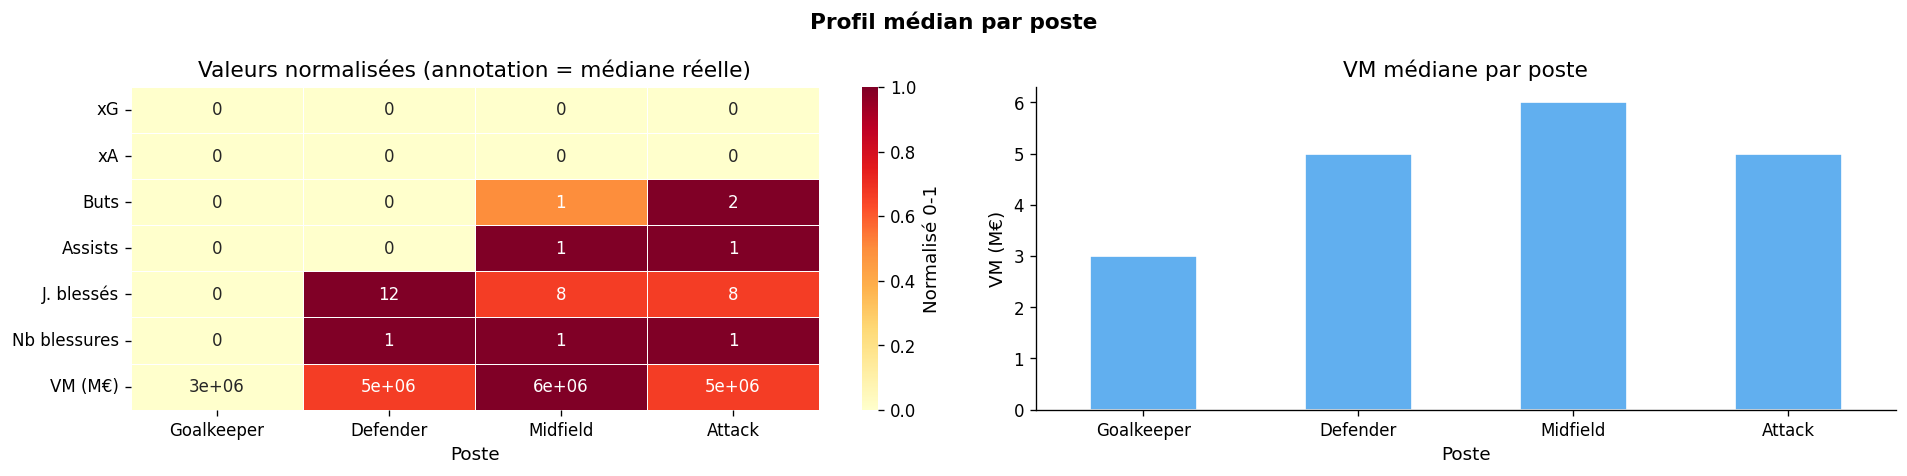

In [14]:
analyser_profil_par_poste(df_base, TARGET, dossier_sauvegarde=dossier_sauvegarde, couleurs_dict=None)

Analyse de la distribution des âges par poste


Graphique sauvegardé sous : ..\outputs\eda\segmentation_par_poste_age_par_poste.png


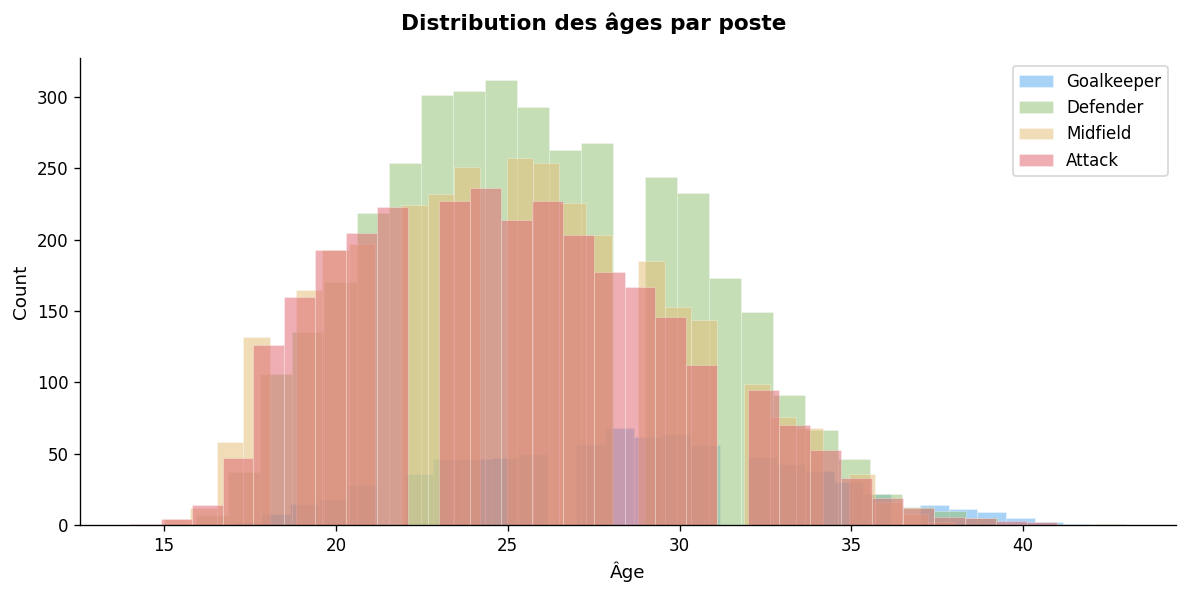


Âge médian par poste
position
Goalkeeper    28.0
Defender      26.0
Midfield      25.0
Attack        25.0


In [15]:
analyser_ages_par_poste(df_base, dossier_sauvegarde=dossier_sauvegarde, liste_couleurs=None)

Analyse croisée : VM médiane par championnat et par poste

Heatmap sauvegardée sous : ..\outputs\eda\feature_engineered_heatmap_league_pos.png


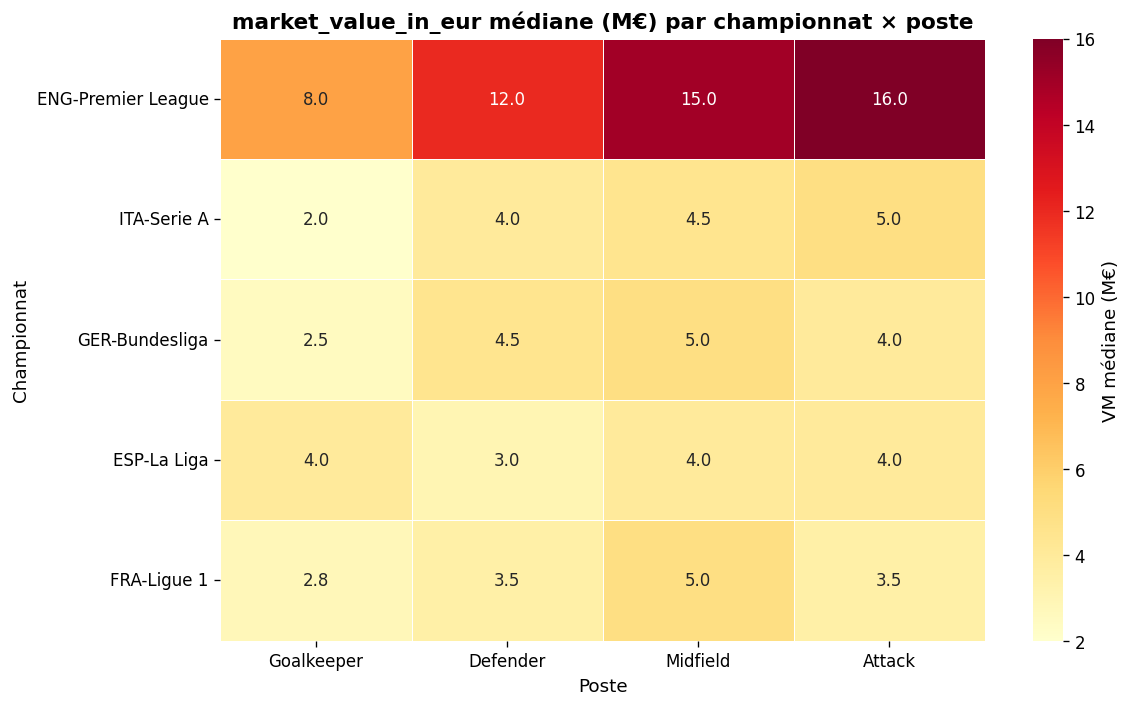

In [16]:
analyser_heatmap_league_poste(df_base, TARGET, dossier_sauvegarde=dossier_sauvegarde)

Analyse de la distribution par championnat

Violin plot sauvegardé sous : ..\outputs\eda\feature_engineered_violin_league.png


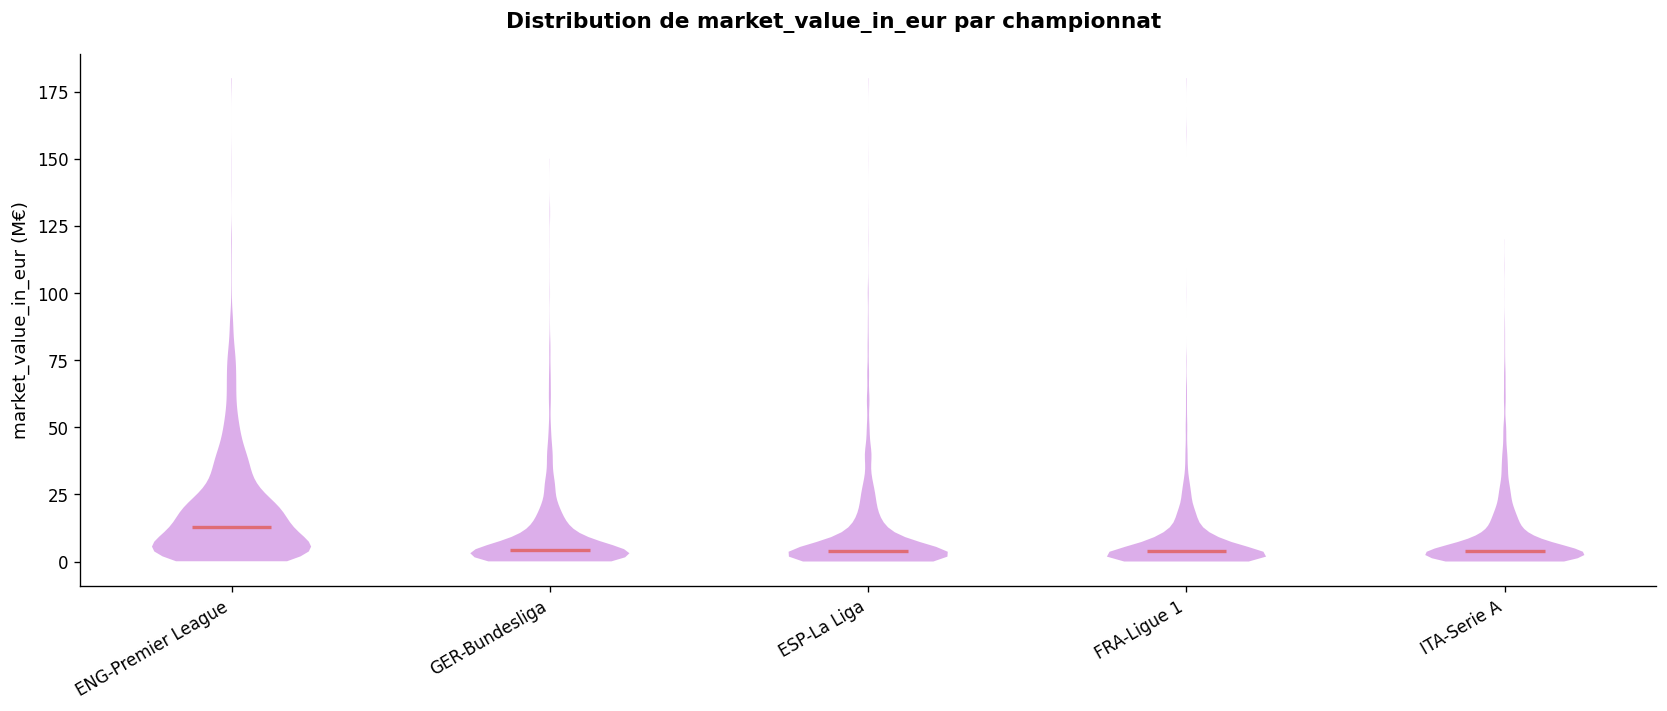

In [17]:
analyser_distribution_violin_league(df_base, TARGET, dossier_sauvegarde=dossier_sauvegarde, couleurs_dict=None)

Analyse des outliers et profils Spécifiques (cible : market_value_in_eur)

Joueurs avec market_value_in_eur ≥ 100M€ : 41 observations

Top 20 des joueurs les plus chers
           player position  age  market_value_in_eur        xg  Performance_Gls  injury_days_total
   Erling Haaland   Attack   22                180.0 32.761400               36               24.0
   Erling Haaland   Attack   23                180.0 31.653997               27               73.0
  Jude Bellingham Midfield   20                180.0 12.974516               19               40.0
    Kylian Mbappé   Attack   25                180.0  0.000000               27                0.0
    Kylian Mbappé   Attack   24                180.0  0.000000               29               14.0
  Vinicius Júnior   Attack   23                180.0  0.000000               15               77.0
    Kylian Mbappé   Attack   23                160.0  0.000000               28               17.0
    Kylian Mbappé   Attack   22        

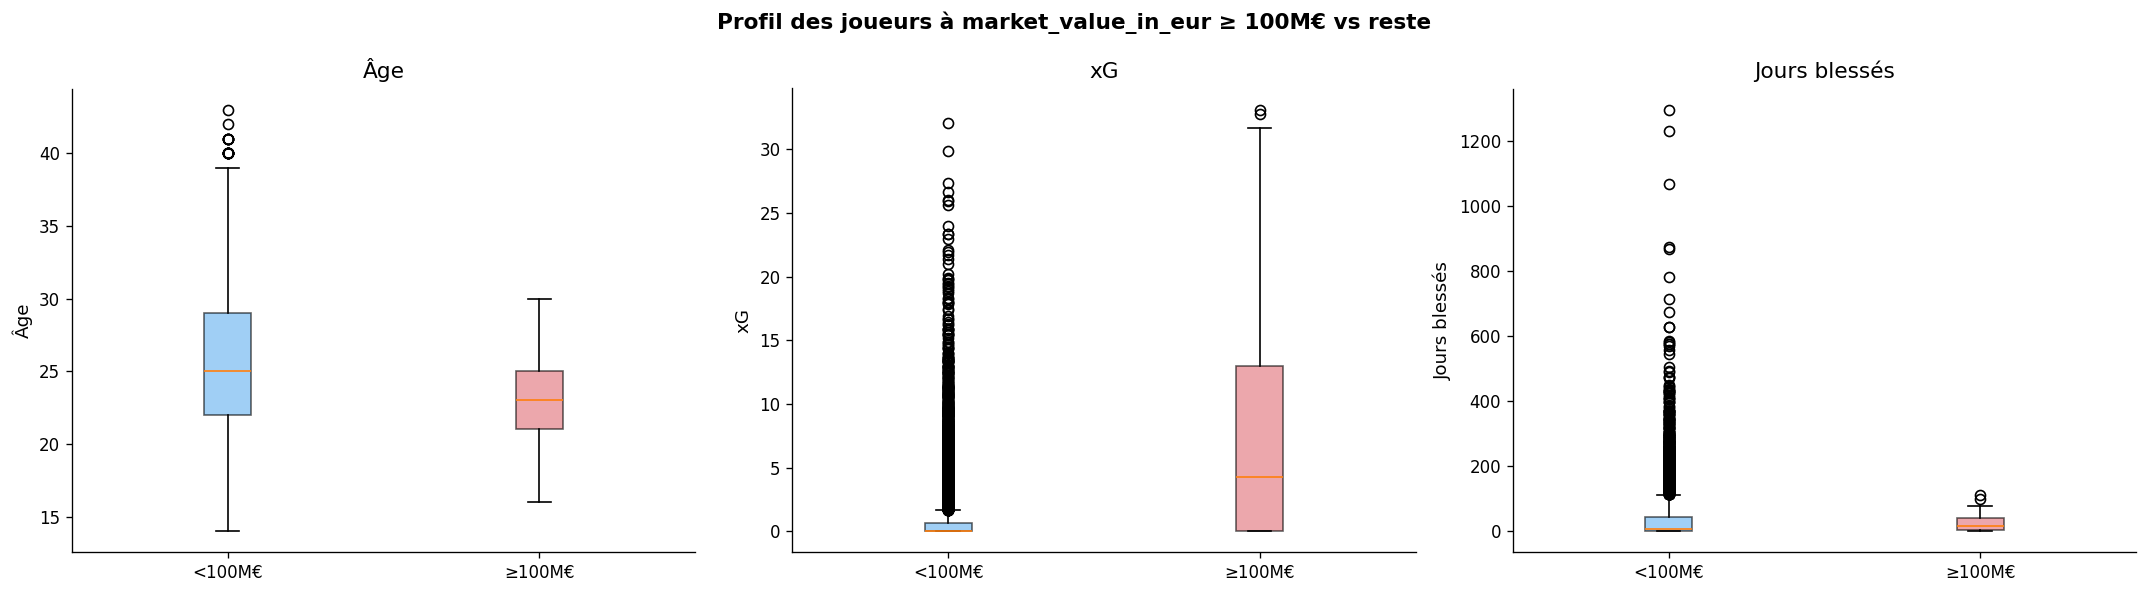

In [18]:
analyser_profil_outliers(df_base, TARGET, dossier_sauvegarde=dossier_sauvegarde, couleurs_dict=None)

In [19]:
verifier_coherence_jours_blessures(df_base)

Contrôle de cohérence : jours de blessures

Cohérence injury_days_total vs somme des composantes (10729/10729 lignes analysées) :
  Cohérents (diff = 0)           : 10,305
  Diff ≤ 1 jour                  : 10,305
  Diff > 1 jour (anomalie)       : 424
  Diff max                       : 1229 jours

Des incohérences ont été détectées. Cela peut provenir de blessures
 qui se chevauchent dans le temps ou de catégories non répertoriées ici.


Analyse de l'évolution temporelle par Saison (cible : market_value_in_eur)

Évolution VM par saison :
             Médiane (M€)  Moyenne (M€)  Nb joueurs
season_year                                        
2020                  5.0     10.589601        2505
2021                  5.0     10.671248        2419
2022                  5.0     11.328877        2476
2023                  5.0     12.144944        2413

Graphique sauvegardé sous : ..\outputs\eda\evolution_temporelle.png


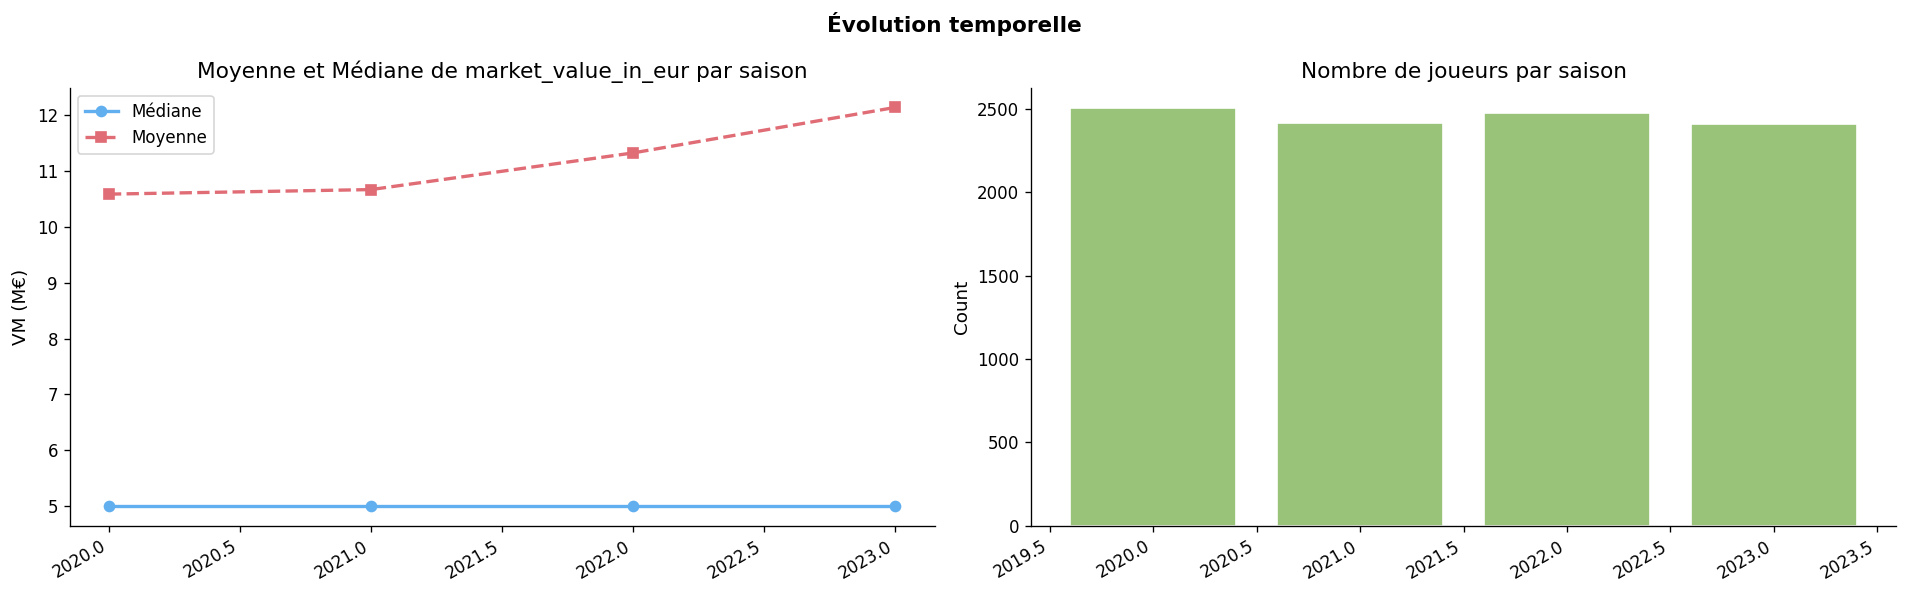

,Médiane (M€),Moyenne (M€),Nb joueurs
season_year,,,
2020,5.0,10.589601,2505
2021,5.0,10.671248,2419
2022,5.0,11.328877,2476
2023,5.0,12.144944,2413


In [20]:
analyser_evolution_temporelle_saison(df_base, TARGET, dossier_sauvegarde=dossier_sauvegarde, couleurs_dict=None)

Démarrage de l'analyse du cycle de vie financier...
10727 observations valides trouvées pour l'analyse graphique.


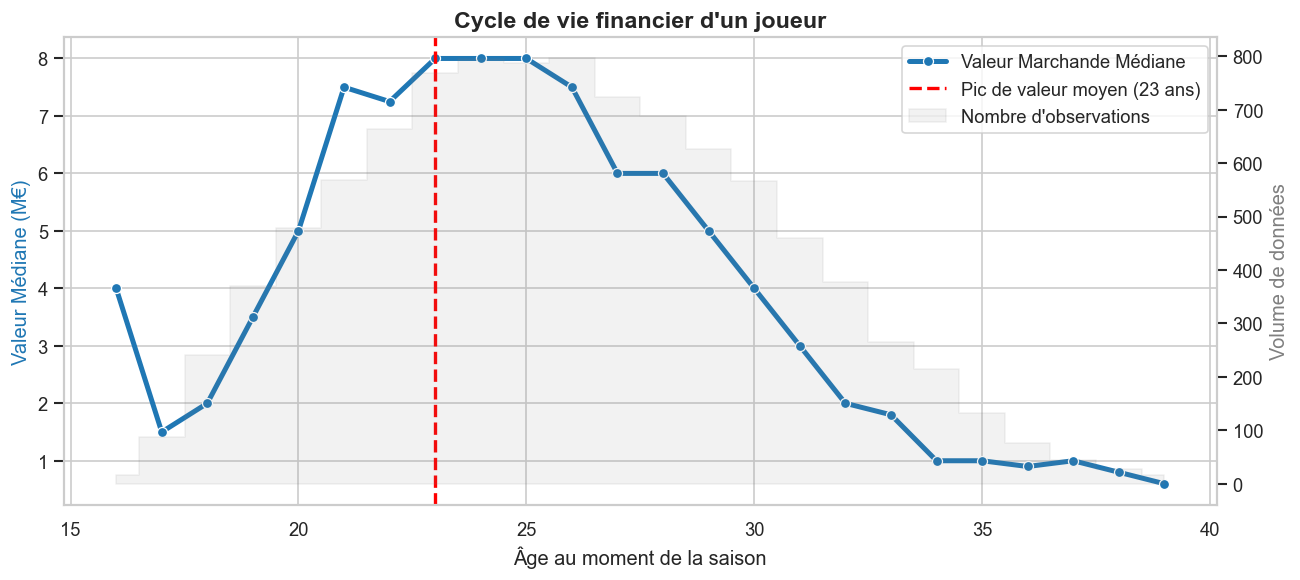


Graphique généré avec succès.


In [21]:
# Application de la fonction
df_base = analyser_cycle_vie_financier(df_base)

Démarrage de l'analyse de distribution des prix...
5 championnats détectés et ordonnés pour l'affichage.


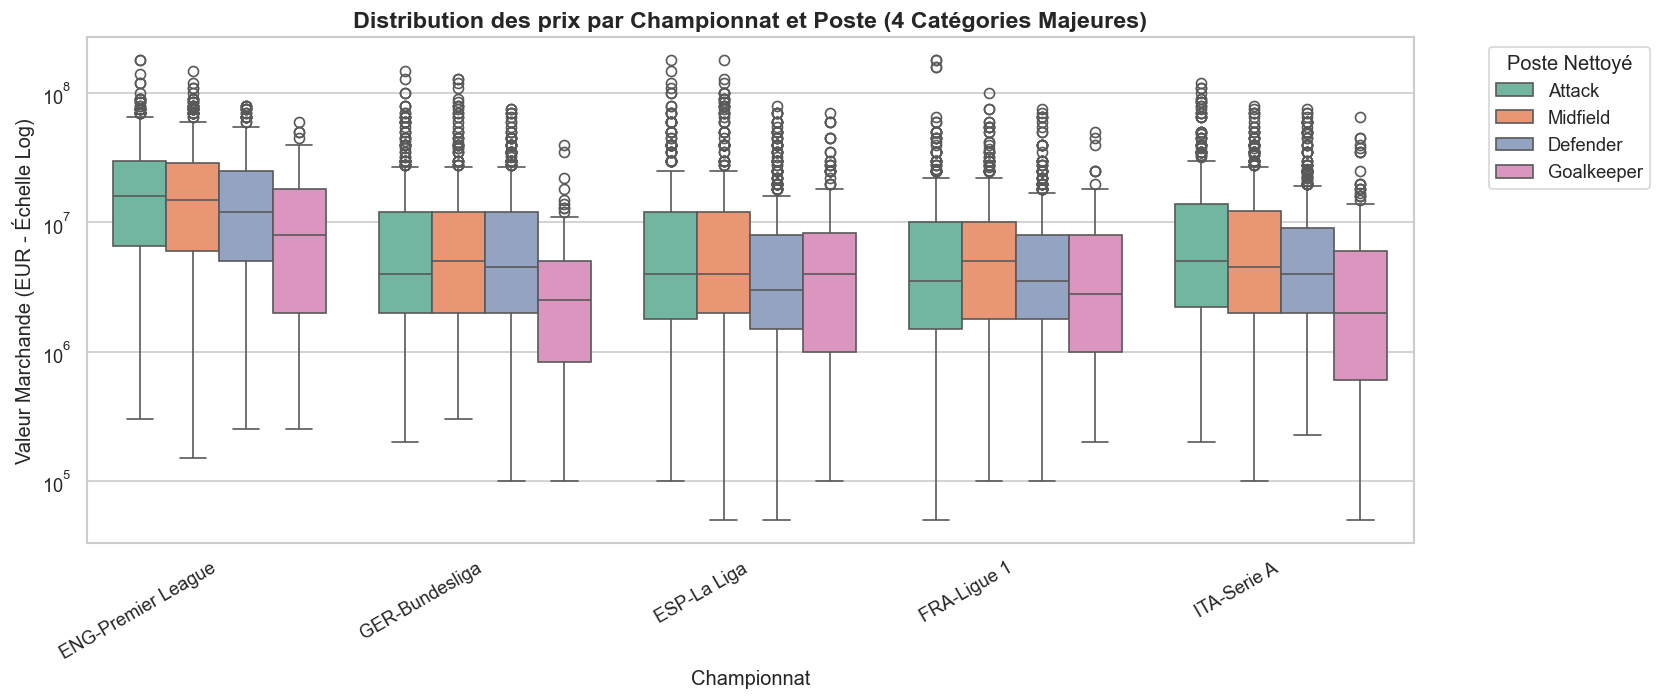


Boxplot généré avec succès.


In [22]:
analyser_distribution_prix_ligue_poste(df_base)

In [23]:
# On détecte les colinéarités
colinearites = detecter_top_colinearites(df_base, top_n=30)

# On affiche le tableau
display(colinearites)

Extraction du Top 30 des colinéarités (hors variables normalisées)...


,Variable_A,Variable_B,Correlation
0,Playing Time_90s,Playing Time_Starts,0.994
1,Performance_G-PK,Performance_Gls,0.978
2,Performance_L,Performance_GA,0.973
3,Performance_Saves,Performance_GA,0.972
4,Performance_PKatt,Performance_PK,0.969
5,pos_GK,Performance_Save%,0.966
6,injury_musculaire_nb_m,injury_musculaire_nb_d,0.960
7,Standard_SoT,Standard_Sh,0.958
8,injury_cheville_pied_nb_m,injury_cheville_pied_nb_d,0.954
9,injury_genou_nb_m,injury_genou_nb_d,0.953


Analyse des variables les plus explicatives pour : market_value_in_eur


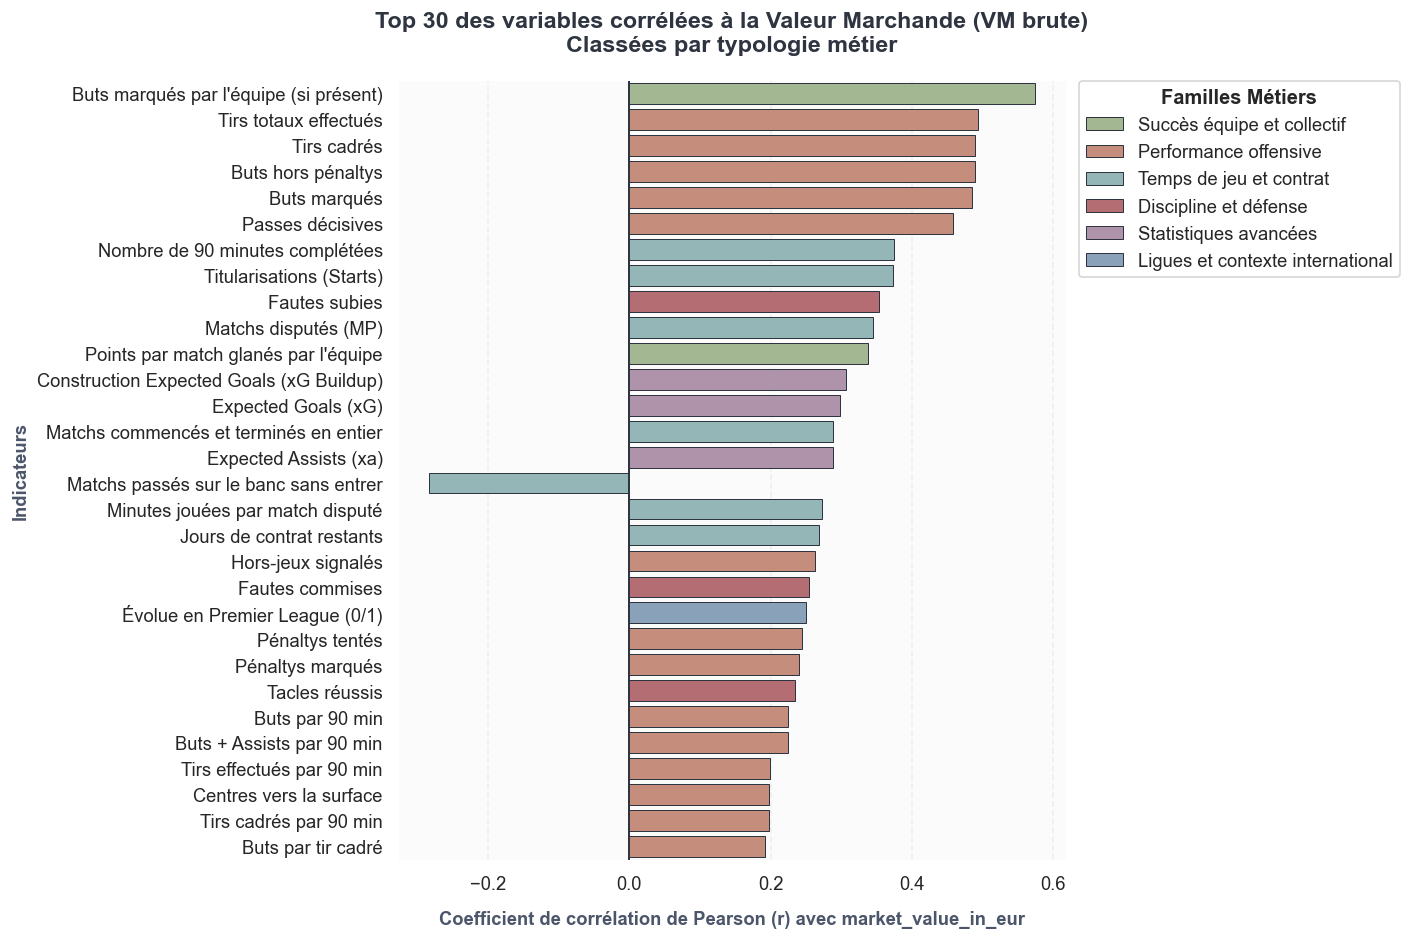

,Variable,Description,Famille,Corr_Cible_Brute
0,Team Success_onG,Buts marqués par l'équipe (si présent),Succès équipe et collectif,0.575
1,Standard_Sh,Tirs totaux effectués,Performance offensive,0.494
2,Standard_SoT,Tirs cadrés,Performance offensive,0.490
3,Performance_G-PK,Buts hors pénaltys,Performance offensive,0.490
4,Performance_Gls,Buts marqués,Performance offensive,0.485
5,Performance_Ast,Passes décisives,Performance offensive,0.459
6,Playing Time_90s,Nombre de 90 minutes complétées,Temps de jeu et contrat,0.375
7,Playing Time_Starts,Titularisations (Starts),Temps de jeu et contrat,0.374
8,Performance_Fld,Fautes subies,Discipline et défense,0.354
9,Playing Time_MP,Matchs disputés (MP),Temps de jeu et contrat,0.345


In [24]:
# On applique la fonction
tableau_importance = analyser_variables_les_plus_explicatives(df_base, target_col=TARGET, top_n=30)

# On affiche le tableau propre sous le graphique
display(tableau_importance)